# **Model Training Phase 1 (with `RandomForestClassifier` and `ExtremeTreesClassifier`)**

In [1]:
%load_ext cudf.pandas

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pickle

# Load the model back
with open('/kaggle/input/datasets/mudarc/my-dataset/df_1.kl', 'rb') as f:
    df = pickle.load(f)

In [3]:
df.head(10)

,id,name,date,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,570306133677760513,cairdin,2015-02-24,Tuesday,11,Eastern_Time,Virgin_America,What said.,Flight Booking Problems,0.00000,0,neutral
1,570301130888122368,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer Service Issue,0.00000,0,positive
2,570301083672813571,yvonnalynn,2015-02-24,Tuesday,11,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight Attendant Complaints,0.00000,0,neutral
3,570301031407624196,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad Flight,0.70330,0,negative
4,570300817074462722,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't Tell,1.00000,0,negative
5,570300767074181121,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,seriously would pay $30 a flight for seats tha...,Can't Tell,0.68420,0,negative
6,570300616901320704,cjmcginnis,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"yes, nearly every time I fly VX this “ear worm...",Customer Service Issue,0.00000,0,positive
7,570300248553349120,pilot,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,Really missed a prime opportunity for Men With...,Customer Service Issue,0.00000,0,neutral
8,570299953286942721,dhepburn,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"Well, I didn't…but NOW I DO! :-D",Customer Service Issue,0.00000,0,positive
9,570295459631263746,YupitsTate,2015-02-24,Tuesday,10,Eastern_Time,Virgin_America,"it was amazing, and arrived an hour early. You...",Bad Flight,0.23895,0,positive


## Removing the unrequired columns
- id
- name
- date

In [4]:
df = df.drop(columns=['id','name','date'])

In [5]:
df['reason'] = df['reason'].str.replace(" ", "_")

In [6]:
df.head(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,Tuesday,11,Eastern_Time,Virgin_America,What said.,Flight_Booking_Problems,0.0000,0,neutral
1,Tuesday,11,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer_Service_Issue,0.0000,0,positive
2,Tuesday,11,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight_Attendant_Complaints,0.0000,0,neutral
3,Tuesday,11,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad_Flight,0.7033,0,negative
4,Tuesday,11,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't_Tell,1.0000,0,negative


## Copying `df` into `data`

In [7]:
data = df.copy()
data.sample(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
10253,Sunday,3,Central_Time,US_Airways,"I was meant to fly on Sat, you just made it Tu...",Cancelled_Flight,0.6777,0,negative
12256,Tuesday,7,Central_Time,American,Is large Wichita Falls Airport not receiving a...,Customer_Service_Issue,0.6611,0,negative
4325,Monday,23,Eastern_Time,United,yes. We waited in line for almost an hour to d...,Late_Flight,0.3460,0,negative
6656,Tuesday,9,Mountain_Time,Southwest,is having a sale! I'm delighted!,Flight_Booking_Problems,0.0000,0,positive
5357,Saturday,8,Atlantic_Time_(Canada),Southwest,"Seriously, is the reason for all the Cancelled...",Cancelled_Flight,0.6558,0,negative


In [8]:
data.select_dtypes(include='object').head()

,day_name,timezone,airlines,feedback,reason,sentiment
0,Tuesday,Eastern_Time,Virgin_America,What said.,Flight_Booking_Problems,neutral
1,Tuesday,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer_Service_Issue,positive
2,Tuesday,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight_Attendant_Complaints,neutral
3,Tuesday,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad_Flight,negative
4,Tuesday,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't_Tell,negative


In [9]:
data.dtypes[data.dtypes == 'object'].reset_index()

,index,0
0,day_name,object
1,timezone,object
2,airlines,object
3,feedback,object
4,reason,object
5,sentiment,object


In [10]:
data.select_dtypes(include='object').nunique()

day_name         7
timezone        78
airlines         6
feedback     14340
reason          10
sentiment        3
dtype: int64

## Making a function to use `tokenization` and `lemmatization`

In [11]:
!pip install cleantext

In [12]:
import nltk
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
stop_words = stopwords.words('english')

from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()

from cleantext import clean

In [13]:
def transform(txt):
    txt = clean(txt, lowercase=True, punct=True)
    txt = word_tokenize(txt)

    temp = [lmt.lemmatize(word, pos='v') for word in txt if word not in stop_words]

    temp2 = temp[:]
    temp2 = " ".join(temp2)

    return temp2

In [14]:
transform('Hello this the God King, playing and singing songs of liberation')

'hello god king play sing songs liberation'

In [15]:
data['day_name'] = data['day_name'].apply(transform)
data['timezone'] = data['timezone'].apply(transform)
data['airlines'] = data['airlines'].apply(transform)
data['feedback'] = data['feedback'].apply(transform)
data['reason'] = data['reason'].apply(transform)

In [16]:
data.sample(10)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
12281,tuesday,7,easterntime,american,communications seem issue,customerserviceissue,1.0000,0,negative
4335,tuesday,11,centraltime,southwest,thank much completely make things right,badflight,0.0000,0,positive
12140,tuesday,9,centraltime,american,extremely upset baggage handlers decide go lug...,damagedluggage,0.6771,0,negative
1412,sunday,21,easterntime,unite,bag leave behind plane overweight great know s...,lostluggage,1.0000,0,negative
4296,tuesday,8,easterntime,unite,day travel swag ijustwanttosleep,customerserviceissue,0.0000,0,neutral
5309,saturday,10,pacifictime,southwest,agents werenot helpful tell would pay 2chng ev...,flightattendantcomplaints,1.0000,0,negative
3640,wednesday,17,easterntime,unite,yes dm,customerserviceissue,0.0000,0,neutral
2234,saturday,17,quito,unite,u serve peanutsnuts yr flight yr policies r co...,lateflight,0.0000,2,neutral
2964,friday,8,pacifictime,unite,email jim compton jeff smisek hopefully pay at...,canttell,0.0000,0,neutral
13840,sunday,19,quito,american,ratchet airway,canttell,0.6556,0,negative


### **Observation** : The above `transform()` function takes the raw string text, and processes them.
Working of the function :- <br>
1. Lowercasing
2. Removing punctuations
3. Removing stopwords
4. Using lemmatization
5. Returning the processes text


## Using label encoder on sentiment

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data[['sentiment']] = le.fit_transform(data[['sentiment']]) 

In [18]:
le.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [19]:
data.head(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,tuesday,11,easterntime,virginamerica,say,flightbookingproblems,0.0000,0,1
1,tuesday,11,pacifictime,virginamerica,plus youve add commercials experience tacky,customerserviceissue,0.0000,0,2
2,tuesday,11,centraltime,virginamerica,didnt today must mean need take another trip,flightattendantcomplaints,0.0000,0,1
3,tuesday,11,pacifictime,virginamerica,really aggressive blast obnoxious entertainmen...,badflight,0.7033,0,0
4,tuesday,11,pacifictime,virginamerica,really big bad thing,canttell,1.0000,0,0


### **Observation** : Using `LabelEncoder` on sentiment labels each of the classes into numbers
Labels : 
- negative - 0
- neutral - 1
- positive - 2

## Using vectorization to convert all the text into vectors

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#### Using `ColumnTransformer` to add the needed columns to make one single column `combined_labels`

In [21]:
data['combined_labels'] = data[['day_name','timezone','airlines','reason']].astype(str).agg(' '.join, axis=1)
data.sample(6)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment,combined_labels
8549,wednesday,14,centraltime,delta,great idea cometoaustin,lateflight,0.393015,0,2,wednesday centraltime delta lateflight
7297,sunday,18,greenland,delta,potentially stressful situation reflight book ...,flightattendantcomplaints,0.387900,0,0,sunday greenland delta flightattendantcomplaints
7911,friday,20,pacifictime,delta,wont site let book ticket nov jfk kin,flightbookingproblems,0.662000,0,0,friday pacifictime delta flightbookingproblems
6745,tuesday,0,pacifictime,southwest,cool bag take bite longer dont give baggage bl...,customerserviceissue,0.345100,0,0,tuesday pacifictime southwest customerservicei...
13140,monday,10,atlantictimecanada,american,hold 2nd time today need help confirm new flig...,flightbookingproblems,0.342200,0,0,monday atlantictimecanada american flightbooki...
4015,tuesday,18,easterntime,unite,referral program milageplus explorer card,canttell,0.000000,0,1,tuesday easterntime unite canttell


In [22]:
processor = ColumnTransformer(
    transformers=[
        ('labels_tf', TfidfVectorizer(ngram_range=(1,1)), 'combined_labels'),
        ('sentence_tf', TfidfVectorizer(ngram_range=(2,2)), 'feedback'),
        ('minmax', MinMaxScaler(), ['hour']),
        ('standard', StandardScaler(), ['reason_confidence', 'retweets'])
    ],
    remainder='drop'            # will drop rest of the unnecessary columns
)


#### Storing the vector form of data in `x`

In [23]:
x = processor.fit_transform(data)
print(len(x.toarray()))
x.toarray()

14640


array([[ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
         0.49054576, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799]], shape=(14640, 81063))

In [24]:
y = data['sentiment'].values
y

array([1, 2, 1, ..., 1, 0, 1], shape=(14640,))

### **Observation** :
- Here we have used `ColumnTransformer` to transform columns into required columns
    1. First we used `TfidfVectorizer` with `ngram_range` of (1,1) on the **combined_labels** because, the original labels (day_name, timezone, airlines, reason) contained one word classes. So creating a `Unigram` was a much better idea, so that the model can focus separately on each classes.
        - Here using bigram would not be a good idea.
    2. Secondly we use `TfidfVectorizer` with `ngram_range` of (2,2) on the **feedback** because, to catch the sentiments in a completely text based data would be much better rather than going for unigram or trigram
        - If unigram was used, then it would have lost the syntaxtical meaning of the data.
        - If `ngram_range` with (1,3) was used, then it would have unncessarily have created large number of unnecessary features. Which could have lead to overfitting.
    3. Third `MinMaxScaler` was used on hour, as we know the minimum and maximum value of hour, which is btwn 0 to 23.
    4. Fourth we used `StandardScaler` on reason_confidence and retweets because the minimum and maximum number was not fixed for both of these, and hence both these features became mean centered.

# Training the model

#### Converting `x` in to `float32` and `y` into `int32`

In [25]:
# Convert features to float32
x = x.astype('float32')

# Convert labels to int32 (for classification) or float32 (for regression)
y = y.astype('int32')

In [ ]:
from sklearn.model_selection import train_test_split as ttt

x_train, x_test, y_train, y_test = ttt(x, y, test_size=0.3, random_state=42)

# Extract into clean NumPy arrays (stored on CPU RAM to support clean KFold indexing)
if hasattr(x_train, "toarray"):
    x_train = x_train.toarray()
    x_test = x_test.toarray()
else:
    x_train = np.array(x_train)
    x_test = np.array(x_test)

# Converting labels into matching NumPy array format
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training array setup on CPU safely. Shape:", x_train.shape)

Training array setup on CPU safely. Shape: (10248, 81063)


# Using `optuna` to find the best model 
- Using `RandomForestClassifier` and `ExtraTreesClassifier`

In [ ]:
import optuna
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as ttt
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
x_tr, x_val, y_tr, y_val = ttt(x_train, y_train, test_size=0.2, random_state=42)                     # creating a new train test split to for model training

def model(trial):
    # selecting the model name
    classifier_name = trial.suggest_categorical('classifier', ['RandomForestClassifier', 'ExtraTreesClassifier'])

    # setting the global parameters to for both the models
    n_estimators = trial.suggest_int('n_estimators', 50, 150, step=50)
    max_features = trial.suggest_float('max_features', 0.001, 0.05)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Model -- RandomForestClassifier
    if classifier_name == 'RandomForestClassifier':
        max_depth = trial.suggest_int('max_depth', 5, 16)

        clf = cuRF(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Model -- ExtraTreesClassifier
    else:
        max_depth = trial.suggest_int('max_depth', 5, 25)

        clf = ExtraTreesClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )

    clf.fit(x_tr, y_tr)
    preds = clf.predict(x_val)
    
    return accuracy_score(y_val, preds)             # while making a function for optuna we can directly return the predicted values, but on drawback is we can't use optuna on it.
    # to use optuna we need to return a single number, in this case it is the accuracy_score

In [28]:
x_train.shape

(10248, 81063)

#### Creating a `study` for optuna
- To run optuna, we need to create a `study`, then we have to optimize it mentioning how many number of times we need to run the function using `n_trials` (in this case `model()`)

In [29]:
study = optuna.create_study(direction='maximize')
study.optimize(model, n_trials=6)

best_params = study.best_params
classifier_name = best_params.pop('classifier')

[I 2026-05-28 03:33:59,601] A new study created in memory with name: no-name-f551d455-af7c-42a2-b9ea-61ee288cb584
[I 2026-05-28 03:34:12,252] Trial 0 finished with value: 0.6209756097560976 and parameters: {'classifier': 'RandomForestClassifier', 'n_estimators': 150, 'max_features': 0.0034507730502925486, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_depth': 16}. Best is trial 0 with value: 0.6209756097560976.
[I 2026-05-28 03:35:32,025] Trial 1 finished with value: 0.6297560975609756 and parameters: {'classifier': 'ExtraTreesClassifier', 'n_estimators': 100, 'max_features': 0.01719878579663047, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_depth': 21}. Best is trial 1 with value: 0.6297560975609756.
[I 2026-05-28 03:37:23,484] Trial 2 finished with value: 0.6341463414634146 and parameters: {'classifier': 'ExtraTreesClassifier', 'n_estimators': 100, 'max_features': 0.017134109533629, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_depth': 22}. Best is trial 2 with val

## Making a `if else` statement for each of the model, and setting their parameters with the best parameters received from the `study`

In [ ]:
if classifier_name == 'RandomForestClassifier':
    final_model = cuRF(**best_params, random_state=42)
elif classifier_name == 'ExtraTreesClassifier':
    final_model = ExtraTreesClassifier(**best_params, random_state=42, n_jobs=-1)

# making prediction
final_model.fit(x_train, y_train)
final_preds = final_model.predict(x_test)
final_accuracy = accuracy_score(y_test, final_preds)

## Printing the best parameters and best accuracy

In [31]:
print("Best Parameters:", study.best_params)
print()
print("Final Test Accuracy:", final_accuracy)

Best Parameters: {'classifier': 'RandomForestClassifier', 'n_estimators': 50, 'max_features': 0.02387602366450517, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_depth': 15}

Final Test Accuracy: 0.671448087431694


### **Observation** : As we can see above out of all 6 trials the best model with best parameters we received are ;
- Best Model : `RandomForestClassifier`
- Best Parameters : 
    - `n_estimators` : 50
    - `max_features` : 0.02387602366450517
    - `min_samples_split` : 17
    - `min_samples_leaf` : 5
    - `max_depth` : 15
- Best Accuracy : **0.671448087431694 | (67 %)**

## Checking for accuracy with different metrics

In [32]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

In [33]:
print(f"PRECISION SCORE : {precision_score(y_test, final_preds, average='weighted')}")
print()
print(f"RECALL SCORE    : {recall_score(y_test, final_preds, average='weighted')}")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(final_preds, y_test)}")

PRECISION SCORE : 0.7382911378765297

RECALL SCORE    : 0.671448087431694

CONFUSION MATRIX : 
[[2813  778  632]
 [   1  106   32]
 [   0    0   30]]


### **Observation** :

* **Test Accuracy (67.14%):** The model correctly classifies the sentiment for approximately 67 out of every 100 tweets in the unseen test set. While this outperforms a random baseline, the model still misclassifies over 32% of the dataset.
* **Precision (73.83%):** This is the model's strongest metric. When the model predicts a specific sentiment class, it is correct nearly 74% of the time. This indicates a relatively low rate of False Positives (false alarms).
* **Recall (67.14%):** The model successfully captures 67.14% of the actual sentiment cases. It is completely missing or mislabeling roughly 33% of the true target sentiments (False Negatives).


Based on the setup of the notebook pipeline, the model shows strong characteristics of **Overfitting**:
* **The Effect:** The classifier is likely memorizing hyper-specific phrases, rare typos, or specific usernames present only in the training set. When evaluated on the test set, these noisy features do not exist, causing the performance to drop to the **67.14%** mark.

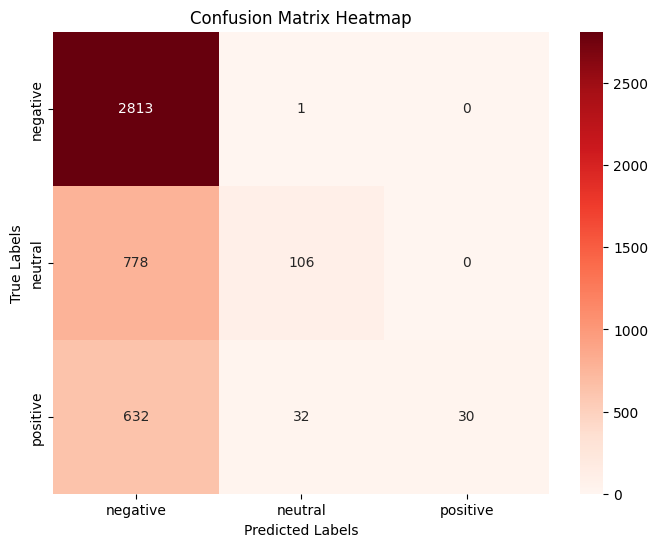

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### **Observation** :

#### 1. Severe Prediction Bias (Class 0 Dominance)
* **The Issue:** The model overwhelmingly defaults to predicting **0 (negative)** regardless of the actual class. 
* **The Numbers:** Out of **4,392 total test samples**, the model predicted class 0 a staggering **4,223 times** (approx. 96.1% of all predictions).
* **Impact:** While the recall for the negative class is near-perfect ($2813 / 2814 \approx 99.9\%$), this is an illusion of high accuracy caused by the model playing it "safe" and choosing the majority class.

#### 2. High Misclassification Rates (False Negatives)
* **Class 1 (neutral):** Out of 884 true neutral samples, **778** were misclassified as negative. The model only correctly identified 106 neutral cases.
* **Class 2 (positive):** Out of 694 true positive samples, **632** were misclassified as negative. Only 30 positive cases were correctly captured.
* **Impact:** The model is almost completely blind to features that differentiate "neutral" and "positive" from "negative".

#### 3. Likely Causes & Action Plan
* **Class Imbalance:** Training dataset is highly likely dominated by negative samples, forcing the model to learn that predicting "negative" yields the highest baseline accuracy.
* **Lack of Convergence:** The model might not have trained long enough to pick up the subtle nuances of the minority classes (neutral and positive).